# Model Predictiu: Arbres de decisió

## Model predictiu 1

A continuació dissenyarem un model de predicció de tipus arbre de decisió per predir l'abandonament dels clients a la companyia de telecomunicacions i farem una sèrie de variacions per trobar el model més òptim. 

Ajuntem els 3 dataframes corresponents als 3 fitxers csv que contenen les dades sobre els clients en un sol, ja que volem predir la columna d'abandonament en funció de TOTES les altres i d'aquesta forma simplifiquem les coses. 

In [893]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
import numpy as np

In [894]:
df_aband=pd.read_csv('abandonament.csv')
df_demo=pd.read_csv('clients.csv')
df_internet=pd.read_csv('internet.csv')

df=df_aband.merge(df_demo, on='customerID', how='outer')
df=df.merge(df_internet, on='customerID', how='outer')
df.drop('customerID',axis=1,inplace=True)
df

,tenure,PhoneService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,gender,SeniorCitizen,Partner,Dependents,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,9,Yes,One year,Yes,Mailed check,65.60,,No,Female,0,Yes,Yes,No,DSL,No,Yes,No,Yes,Yes,No
1,9,Yes,Month-to-month,No,Mailed check,59.90,542.4,No,Male,0,No,No,Yes,DSL,No,No,No,No,No,Yes
2,4,Yes,Month-to-month,Yes,Electronic check,73.90,280.85,Yes,Male,0,No,No,No,Fiber optic,No,No,Yes,No,No,No
3,13,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,Yes,Male,1,Yes,No,No,Fiber optic,No,Yes,Yes,No,Yes,Yes
4,3,Yes,Month-to-month,Yes,Mailed check,83.90,267.4,Yes,Female,1,Yes,No,No,Fiber optic,No,No,No,Yes,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7037,13,Yes,One year,No,Mailed check,55.15,742.9,No,Female,0,No,No,No,DSL,Yes,No,No,Yes,No,No
7038,22,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7,Yes,Male,0,Yes,No,Yes,Fiber optic,No,No,No,No,No,Yes
7039,2,Yes,Month-to-month,Yes,Mailed check,50.30,,No,Male,0,No,No,No,DSL,No,Yes,No,No,No,No
7040,67,Yes,Two year,No,Mailed check,67.85,4627.65,No,Male,0,Yes,Yes,No,DSL,Yes,No,Yes,Yes,No,Yes


Com que la biblioteca que utilitzarem és `sklearn`, el primer pas de tots serà transformar totes les variables categòriques a numèriques, ja que la biblioteca solament permet operar amb aquestes.

La variable que volem predir és l'abandonament i, per tant, l'assignem la variable y.

In [897]:
y=df['Churn'].map({'No':0, 'Yes':1})

La resta de columnes seran les candidates a fer la predicció, les transformem també. 

In [899]:
X = pd.DataFrame({
    'gender': df['gender'].map({'Female': 0, 'Male': 1}),
    'SeniorCitizen': df['SeniorCitizen'],
    'Partner': df['Partner'],
    'Dependents': df['Dependents'].map({'No': 0, 'Yes': 1}),
    'tenure': df['tenure'],
    'PhoneService': df['PhoneService'].map({'No': 0, 'Yes': 1}),
    'Contract': df['Contract'],
    'PaperlessBilling': df['PaperlessBilling'].map({'No': 0, 'Yes': 1}),
    'PaymentMethod': df['PaymentMethod'],
    'MonthlyCharges': df['MonthlyCharges'],
    'MultipleLines': df['MultipleLines'],
    'InternetService': df['InternetService'],
    'OnlineSecurity': df['OnlineSecurity'].map({'No': 0, 'No internet service': 0,'Yes': 1}), # considerem 'No internet service' com a 'No'
    'OnlineBackup': df['OnlineBackup'].map({'No': 0, 'No internet service': 0,'Yes': 1}),
    'DeviceProtection': df['DeviceProtection'].map({'No': 0, 'No internet service': 0,'Yes': 1}),
    'TechSupport': df['TechSupport'].map({'No': 0, 'No internet service': 0,'Yes': 1}),
    'StreamingTV': df['StreamingTV'].map({'No': 0, 'No internet service': 0,'Yes': 1}),
    'StreamingMovies': df['StreamingMovies'].map({'No': 0, 'No internet service': 0,'Yes': 1}),
    'TotalCharges': df['MonthlyCharges'] * df['tenure'] # reemplacem la columna 'TotalCharges' per el que paguen al mes multiplicat pels mesos  
})
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

X['MonthlyCharges_scaled'] = scaler.fit_transform(X[['MonthlyCharges']])
X['tenure_scaled'] = scaler.fit_transform(X[['tenure']])
X['TotalCharges_scaled'] = scaler.fit_transform(X[['TotalCharges']])
X.drop('MonthlyCharges', axis=1, inplace=True)
X.drop('tenure', axis=1, inplace=True)
X.drop('TotalCharges', axis=1, inplace=True)
X=pd.get_dummies(X, columns=['Partner'],dummy_na=True, dtype=int, drop_first=True)
X=pd.get_dummies(X, columns=['Contract','PaymentMethod','MultipleLines','InternetService'],dtype=int, drop_first=True)
X

,gender,SeniorCitizen,Dependents,PhoneService,PaperlessBilling,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,...,Partner_nan,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No
0,0,0,1,1,1,0,1,0,1,1,...,0,1,0,0,0,1,0,0,0,0
1,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,0
2,1,0,0,1,1,0,0,1,0,0,...,0,0,0,0,1,0,0,0,1,0
3,1,1,0,1,1,0,1,1,0,1,...,0,0,0,0,1,0,0,0,1,0
4,0,1,0,1,1,0,0,0,1,1,...,0,0,0,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7037,0,0,0,1,0,1,0,0,1,0,...,0,1,0,0,0,1,0,0,0,0
7038,1,0,0,1,1,0,0,0,0,0,...,0,0,0,0,1,0,0,1,1,0
7039,1,0,0,1,1,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
7040,1,0,1,1,0,1,0,1,1,0,...,0,0,1,0,0,1,0,0,0,0


Un cop ja tenim el dataframe preparat per poder utilitzar la biblioteca de creació de models predictius `sklearn`, dividim el conjunt en un d'entrenament i en un de prova.

In [978]:
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=5)

## IMPORTANT!!! 

A causa d'un error a l'hora de dividir les dades en dataframes de prova i entrenament (depenent de l'ordinador ho feia d'una forma o altra independentment del paràmetre `random_state()`) hem decidit importar els dataframes fets a un sol ordinador i utilitzar-los en els diferents notebooks per mantenir l'homogeneïtat de les dades. 

In [904]:
X_train=pd.read_csv('X_train.csv')
X_test=pd.read_csv('X_test.csv')
y_train=pd.read_csv('y_train.csv')
y_test=pd.read_csv('y_test.csv')

Creem un primer model predictiu "arbre de decisió" de prova.

Text(0.5, 1.0, 'Predicció abandonament Model de Prova')

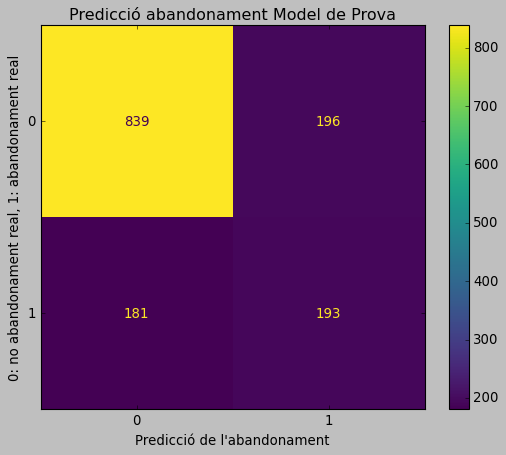

In [996]:
model = tree.DecisionTreeClassifier(random_state=5)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot()
plt.xlabel("Predicció de l'abandonament")
plt.ylabel('0: no abandonament real, 1: abandonament real')
plt.title('Predicció abandonament Model de Prova')

Calculem l'exactitud.

In [908]:
exactitud=round(model.score(X_test,y_test)*100,2)
exactitud

73.24

Com que en aquest cas la taxa d'abandonament és més baixa que la de permanència, millor utilitzarem com a avaluador del rendiment del model la `f1_score`. Aquesta mètrica és la mitja harmònica de la precisió i el recall que són mètriques més fiables per a models desequilibrats com en aquest cas. Durant el següent notebook la precisió i el recall són sobre la classe 1 (aquells que abandonen). 

La calculem com a prova amb els paràmetres predeterminats com en el cas anterior. 

In [910]:
f1=round(f1_score(y_test,y_pred)*100,2)
f1

50.59

Veiem que l'exactitud voreja el 70%, però la f1 el 50% el que significa que dels que abandonen, aquest model aproximadent encerta la meitat. Per intentar augmentar aquest rendiment provarem diferents paràmetres per al model.


- Màxima profunditat (`max_depth`):

Primer comencem per experimentat amb el `max_depth`, que regula la profunditat de l'arbre i evita així el sobre ajustament. 

Text(7, 57.96, '(6, 56.46)')

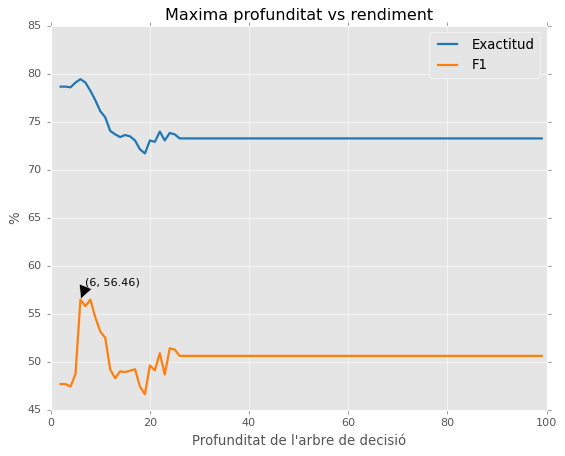

In [1030]:
maxima_profunditat=list(range(2,100))
l_e=[]
l_p=[]

for valor in maxima_profunditat:
    model = tree.DecisionTreeClassifier(max_depth=valor,random_state=5)
    model.fit(X_train, y_train)
    
    # Hacer predicciones
    y_pred = model.predict(X_test)

    exactitud = round(model.score(X_test,y_test)*100,10)
    f1=round(f1_score(y_test,y_pred)*100,2)
    l_e.append(exactitud)
    l_p.append(f1)

plt.plot(maxima_profunditat, l_e, label='Exactitud', color='#1f77b4')
plt.plot(maxima_profunditat, l_p, label='F1', color='#ff7f0e')
plt.title("Maxima profunditat vs rendiment")
plt.xlabel("Profunditat de l'arbre de decisió")
plt.ylabel('%')
plt.ylim(45,85)
plt.legend()
plt.style.use('ggplot')
 # trobar el punt més alt
max_idx = l_p.index(max(l_p))
x_max = maxima_profunditat[max_idx]
y_max = l_p[max_idx]
    
# anotar tant l'X com l'Y just sobre el punt
plt.annotate(f'({max_x}, {max_y:.2f})',
                xy=(x_max, y_max), 
             xytext=(x_max + 1, y_max + 1.5),
             arrowprops=dict(facecolor='black', shrink=0.05,mutation_scale=5),
             fontsize=10,
             color='black')

Com es pot observar, en aquest cas la màxima profunditat ideal i que proporciona una F1 més elevada es troba en 6. 


- Mínim de mostres per la divisió (`min_samples_split`):

Provarem ara un altre paràmetre anomenat `min_samples_split` que bàsicament és el nombre mínim de mostres que ha de tenir un node per dividir-se, per defecte són dos.  

Text(203, 58.43, '(202, 56.93)')

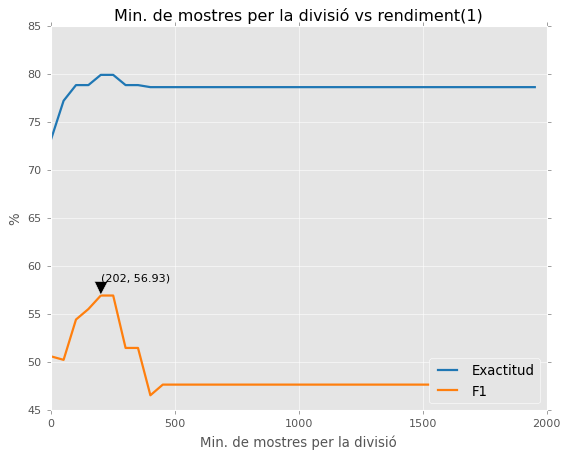

In [1028]:
div=list(range(2,2000,50))
l_e=[]
l_p=[]

for valor in div:
    model = tree.DecisionTreeClassifier(min_samples_split=valor,random_state=5)
    model.fit(X_train, y_train)
    
    # Hacer predicciones
    y_pred = model.predict(X_test)

    exactitud = round(model.score(X_test,y_test)*100,10)
    f1=round(f1_score(y_test,y_pred)*100,2)
    l_e.append(exactitud)
    l_p.append(f1)

plt.plot(div, l_e, label='Exactitud', color='#1f77b4')
plt.plot(div, l_p, label='F1', color='#ff7f0e')
plt.title("Min. de mostres per la divisió vs rendiment(1)")
plt.xlabel("Min. de mostres per la divisió")
plt.ylabel('%')
plt.ylim(45,85)
plt.legend(loc='lower right')
 # trobar el punt més alt
max_idx = l_p.index(max(l_p))
x_max = div[max_idx]
y_max = l_p[max_idx]
    
# anotar tant l'X com l'Y just sobre el punt
plt.annotate(f'({x_max}, {y_max:.2f})',
                xy=(x_max, y_max), 
             xytext=(x_max + 1, y_max + 1.5),
             arrowprops=dict(facecolor='black', shrink=0.05,mutation_scale=5),
             fontsize=10,
             color='black')

Veiem com quedaria combinant-lo amb el paràmetre de màxima profunditat.

Text(203, 58.9, '(202, 57.40)')

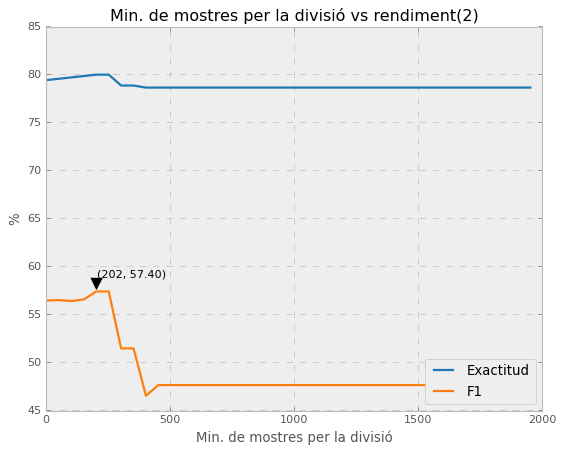

In [1024]:
div=list(range(2,2000,50))
l_e=[]
l_p=[]

for valor in div:
    model = tree.DecisionTreeClassifier(min_samples_split=valor,max_depth=6,random_state=5)
    model.fit(X_train, y_train)
    
    # Hacer predicciones
    y_pred = model.predict(X_test)

    exactitud = round(model.score(X_test,y_test)*100,10)
    f1=round(f1_score(y_test,y_pred)*100,2)
    l_e.append(exactitud)
    l_p.append(f1)

plt.plot(div, l_e, label='Exactitud', color='#1f77b4')
plt.plot(div, l_p, label='F1', color='#ff7f0e')
plt.title("Min. de mostres per la divisió vs rendiment(2)")
plt.xlabel("Min. de mostres per la divisió")
plt.ylabel('%')
plt.ylim(45,85)
plt.legend(loc='lower right')
plt.style.use('ggplot')
# trobar el punt més alt
max_idx = l_p.index(max(l_p))
x_max = div[max_idx]
y_max = l_p[max_idx]
    
# anotar tant l'X com l'Y just sobre el punt
plt.annotate(f'({x_max}, {y_max:.2f})',
                xy=(x_max, y_max), 
             xytext=(x_max + 1, y_max + 1.5),
             arrowprops=dict(facecolor='black', shrink=0.05,mutation_scale=5),
             fontsize=10,
             color='black')

Veiem que afegint el paràmetre de `min_samples_split` i combinant-lo amb el de profunditat mínima amb el seu valor òptim augmenten la F1, per tant ens quedarem amb aquesta combinació. 

- Nombre de característiques per fer la divisió (`max_features`):

Ara provarem amb el `max_features`, que bàsicament determina el nombre de característiques per fer la divisió. 

Text(12, 52.43, '(11, 50.93)')

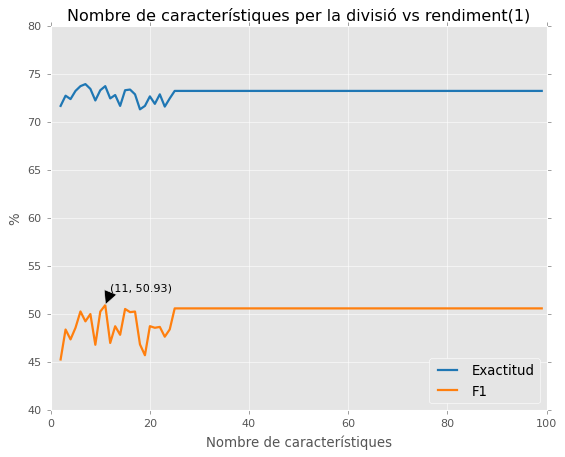

In [1026]:
n_caracteristiques=list(range(2,100))
l_e=[]
l_p=[]

for valor in n_caracteristiques:
    model = tree.DecisionTreeClassifier(max_features=valor,random_state=5)
    model.fit(X_train, y_train)
    
    # Hacer predicciones
    y_pred = model.predict(X_test)

    exactitud = round(model.score(X_test,y_test)*100,10)
    f1=round(f1_score(y_test,y_pred)*100,2)
    l_e.append(exactitud)
    l_p.append(f1)

plt.plot(n_caracteristiques, l_e, label='Exactitud', color='#1f77b4')
plt.plot(n_caracteristiques, l_p, label='F1', color='#ff7f0e')
plt.title("Nombre de característiques per la divisió vs rendiment(1)")
plt.xlabel("Nombre de característiques")
plt.ylabel('%')
plt.ylim(40,80)
plt.legend(loc='lower right')
# trobar el punt més alt
max_idx = l_p.index(max(l_p))
x_max = n_caracteristiques[max_idx]
y_max = l_p[max_idx]
    
# anotar tant l'X com l'Y just sobre el punt
plt.annotate(f'({x_max}, {y_max:.2f})',
                xy=(x_max, y_max), 
             xytext=(x_max + 1, y_max + 1.5),
             arrowprops=dict(facecolor='black', shrink=0.05,mutation_scale=5),
             fontsize=10,
             color='black')

Provem amb la `max_depth` i `min_samples_split` òptimes.  

Text(21, 61.15, '(20, 59.65)')

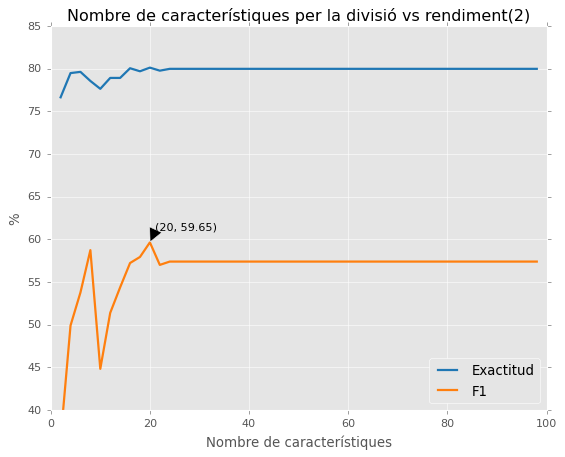

In [1034]:
n_caracteristiques=list(range(2,100,2))
l_e=[]
l_p=[]

for valor in n_caracteristiques:
    model = tree.DecisionTreeClassifier(max_features=valor,max_depth=6,min_samples_split=202,random_state=5)
    model.fit(X_train, y_train)
    
    # Hacer predicciones
    y_pred = model.predict(X_test)

    exactitud = round(model.score(X_test,y_test)*100,10)
    f1=round(f1_score(y_test,y_pred)*100,2)
    l_e.append(exactitud)
    l_p.append(f1)

plt.plot(n_caracteristiques, l_e, label='Exactitud', color='#1f77b4')
plt.plot(n_caracteristiques, l_p, label='F1', color='#ff7f0e')
plt.title("Nombre de característiques per la divisió vs rendiment(2)")
plt.xlabel("Nombre de característiques")
plt.ylabel('%')
plt.ylim(40,85)
plt.legend(loc='lower right')
# trobar el punt més alt
max_idx = l_p.index(max(l_p))
x_max = n_caracteristiques[max_idx]
y_max = l_p[max_idx]
plt.annotate(f'({x_max}, {y_max:.2f})',
                xy=(x_max, y_max), 
             xytext=(x_max + 1, y_max + 1.5),
             arrowprops=dict(facecolor='black', shrink=0.05,mutation_scale=5),
             fontsize=10,
             color='black')

Veiem que hem tornat a augmentar el rendiment del model predictiu fins a quasi el 60%. 

- Pes de les classes (`class_weight`):

Per últim, provarem un altre paràmetre que ens pot ser molt útil i pot canviar l'eficiència del model predictiu. Aquest s'anomena `class_weight`i s'encarrega d'ajustar el pes que té cada classe i és molt útil per equilibrar variables molt descompensades, com efectivament la nostra.  

In [930]:
model = tree.DecisionTreeClassifier(class_weight='balanced',random_state=5)
model.fit(X_train, y_train)
    
   
y_pred = model.predict(X_test)

exactitud = round(model.score(X_test,y_test)*100,10)
f1=round(f1_score(y_test,y_pred)*100,2)
print(f"->Exactitud: {exactitud}, f1: {f1}")

->Exactitud: 73.4563520227, f1: 49.6


Provem amb els altres paràmetres.

->Exactitud: 72.7466288148, f1: 61.52
              precision    recall  f1-score   support

           0       0.91      0.69      0.79      1035
           1       0.49      0.82      0.62       374

    accuracy                           0.73      1409
   macro avg       0.70      0.76      0.70      1409
weighted avg       0.80      0.73      0.74      1409



Text(0.5, 1.0, 'Predicció abandonament Model Inicial')

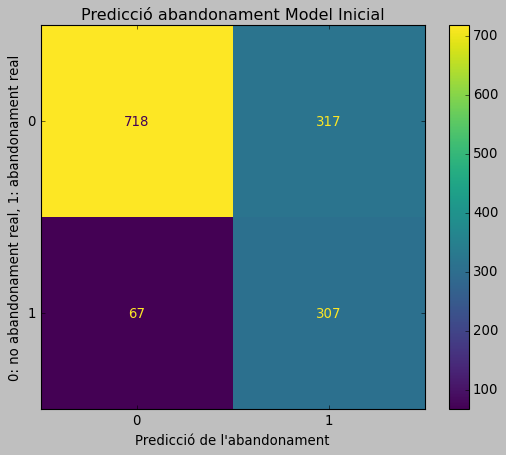

In [988]:
model = tree.DecisionTreeClassifier(class_weight='balanced',max_features=20,max_depth=6,min_samples_split=202,random_state=5)
model.fit(X_train, y_train)
    
   
y_pred = model.predict(X_test)

exactitud = round(model.score(X_test,y_test)*100,10)
f1=round(f1_score(y_test,y_pred)*100,2)
print(f"->Exactitud: {exactitud}, f1: {f1}")
print(classification_report(y_test,y_pred))
cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot()
plt.xlabel("Predicció de l'abandonament")
plt.ylabel('0: no abandonament real, 1: abandonament real')
plt.title('Predicció abandonament Model Inicial')

Observem que amb aquest paràmetre hem aconseguit augmentar encara una mica més el rendiment del model, fins a arribar a una F1 del 61,5%, és a dir que l'hem millorat més d'un 10% després de la implementació de tots aquests paràmetres. 

Cal dir que hi existeix uns quants més de paràmetres pel model d'arbre de decisió. Per exemple tenim el `min_samples_leaf`que ens determina el mínim nombre de mostres perquè el node sigui una fulla (no es divideixi més) o el `max_leaf_nodes` que limita el nombre màxim de fulles que pot tenir l'arbre. Després hi ha d'altres molt més complexos com el `ccp_alpha`que bàsicament és un coeficient que controla la "poda" de l'arbre, com major és més subarbres de l'arbre principal són eliminats. Hem provat tots ells i no incrementaven el rendiment motiu pel qual hem decidit no posar-los.

>En conclusió, em arribat ha la F1 màxima combinant un total de 5 parametres amb els seus valors optims, aquesta F1 (mitjana harmònica de la precisió i el recall) ha sigut del 61,5%.

## Models predictius per selecció de variables






Ara crearem uns altres models predictius on anirem posant variables seleccionades per nosaltres mateixos per veure així si podem augmentar l'eficiència dels models respecte de l'anterior.

El criteri que utilitzarem per determinar quines variables SI utilitzàrem en els nous models predictius serà basant-nos en les variables que en la Regressió Logística hem vist que més afecten en l'abandonament. 
Primer farem un nou conjunt de dades agafant les variables amb un coeficient d'ordre 10e-2 o més gran (descartem els d'ordre 10e-3). Els resultats que es deien obtinguts amb la Regressió Logística són els següents (demostrats en el notebook 'LogisticRegression'): 

In [937]:
#                                   Feature     Coefficient
# 13                    TotalCharges_scaled     1.766739
# 23            InternetService_Fiber optic     0.910452
# 10                        StreamingMovies     0.358048
# 22                      MultipleLines_Yes     0.343912
# 19         PaymentMethod_Electronic check     0.314680
# 9                             StreamingTV     0.313273
# 4                        PaperlessBilling     0.292692
# 21         MultipleLines_No phone service     0.220652
# 1                           SeniorCitizen     0.216953
# 7                        DeviceProtection     0.011749
# 0                                  gender    -0.018087
# 14                            Partner_Yes    -0.044504
# 20             PaymentMethod_Mailed check    -0.072873
# 6                            OnlineBackup    -0.109997
# 18  PaymentMethod_Credit card (automatic)    -0.162661
# 2                              Dependents    -0.176654
# 3                            PhoneService    -0.207724
# 15                            Partner_nan    -0.246131
# 8                             TechSupport    -0.354791
# 5                          OnlineSecurity    -0.400734
# 16                      Contract_One year    -0.791024
# 11                  MonthlyCharges_scaled    -0.929692
# 24                     InternetService_No    -1.054620
# 17                      Contract_Two year    -1.339101
# 12                          tenure_scaled    -3.462762

Cal destacar que moltes de les variables que més influencia tenen al model predictiu són aquelles que anteriorment als objectius vam estudiar. Això ens fa refiar-nos de què aquest coeficient realment faci bé la seva funció.
Per posar un exemple tenim la `tenure` (durada a la companyia) que en aquest cas està expressada com a `tenure_escaled`, ja que la vam normalitzar per poder fer un model més fiable. Aquesta variable mostra un elevat coeficient d'influència i durant la realització dels objectius també vam veure que existia una forta influencia entre aquesta i l'abandonament, per tant, té força sentit.  

Fem la primera selecció segons el primer criteri. 

In [940]:
X_train1 = X_train.copy()
X_train1.drop('DeviceProtection',axis=1,inplace=True)
X_train1.drop('gender',axis=1,inplace=True)
X_train1.drop('Partner_Yes',axis=1,inplace=True)
X_train1.drop('PaymentMethod_Mailed check',axis=1,inplace=True)

X_test1 = X_test.copy()
X_test1.drop('DeviceProtection',axis=1,inplace=True)
X_test1.drop('gender',axis=1,inplace=True)
X_test1.drop('Partner_Yes',axis=1,inplace=True)
X_test1.drop('PaymentMethod_Mailed check',axis=1,inplace=True)

# 'y_train' i 'y_test' seran els mateixos en tots els casos, ja que només són els valors del 'Churn', que és la variable a predir

Fem el model predictiu per aquest nou Dataframe (utilitzarem els paràmetres estudiats anteriorment i que teòricament optimitzen el model).

->Exactitud: 75.088715401, f1: 63.4
              precision    recall  f1-score   support

           0       0.92      0.73      0.81      1035
           1       0.52      0.81      0.63       374

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409



Text(0.5, 1.0, 'Predicció abandonament Model 2')

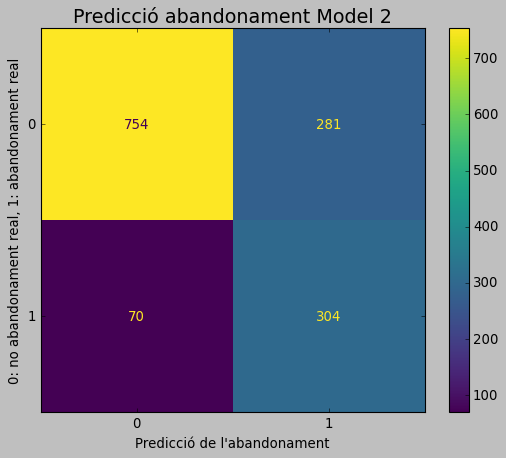

In [1042]:
model = tree.DecisionTreeClassifier(class_weight='balanced',max_features=20,max_depth=6,min_samples_split=202,random_state=5)
model.fit(X_train1, y_train)
    
   
y_pred1 = model.predict(X_test1)

exactitud = round(model.score(X_test1,y_test)*100,10)
f1=round(f1_score(y_test,y_pred1)*100,2)
print(f"->Exactitud: {exactitud}, f1: {f1}")
print(classification_report(y_test,y_pred1))
cm = confusion_matrix(y_test,y_pred1)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot()
plt.style.use('bmh')
plt.xlabel("Predicció de l'abandonament")
plt.ylabel('0: no abandonament real, 1: abandonament real')
plt.title('Predicció abandonament Model 2')

Veiem que ha pujat la F1 de 61,5% a 63,4% i, per tant, hem aconseguit augmentar el rendiment amb aquest procés.

Ara anem a fer un altre model predictiu, però ens quedem només amb les variables que tenen un coeficient en valor absolut més gran o igual a 0.3.

In [944]:
X_train2 = X_train.copy()
X_train2.drop('DeviceProtection',axis=1,inplace=True)
X_train2.drop('gender',axis=1,inplace=True)
X_train2.drop('Partner_Yes',axis=1,inplace=True)
X_train2.drop('PaymentMethod_Mailed check',axis=1,inplace=True)
X_train2.drop('SeniorCitizen',axis=1,inplace=True)
X_train2.drop('MultipleLines_No phone service',axis=1,inplace=True)
X_train2.drop('PaperlessBilling',axis=1,inplace=True)
X_train2.drop('OnlineBackup',axis=1,inplace=True)
X_train2.drop('PaymentMethod_Credit card (automatic)',axis=1,inplace=True)
X_train2.drop('Dependents',axis=1,inplace=True)
X_train2.drop('PhoneService',axis=1,inplace=True)
X_train2.drop('Partner_nan',axis=1,inplace=True)

X_test2 = X_test.copy()
X_test2.drop('DeviceProtection',axis=1,inplace=True)
X_test2.drop('gender',axis=1,inplace=True)
X_test2.drop('Partner_Yes',axis=1,inplace=True)
X_test2.drop('PaymentMethod_Mailed check',axis=1,inplace=True)
X_test2.drop('SeniorCitizen',axis=1,inplace=True)
X_test2.drop('MultipleLines_No phone service',axis=1,inplace=True)
X_test2.drop('PaperlessBilling',axis=1,inplace=True)
X_test2.drop('OnlineBackup',axis=1,inplace=True)
X_test2.drop('PaymentMethod_Credit card (automatic)',axis=1,inplace=True)
X_test2.drop('Dependents',axis=1,inplace=True)
X_test2.drop('PhoneService',axis=1,inplace=True)
X_test2.drop('Partner_nan',axis=1,inplace=True)

->Exactitud: 71.4691270405, f1: 60.59
              precision    recall  f1-score   support

           0       0.91      0.67      0.78      1035
           1       0.48      0.83      0.61       374

    accuracy                           0.71      1409
   macro avg       0.70      0.75      0.69      1409
weighted avg       0.80      0.71      0.73      1409



Text(0.5, 1.0, 'Predicció abandonament Model 3')

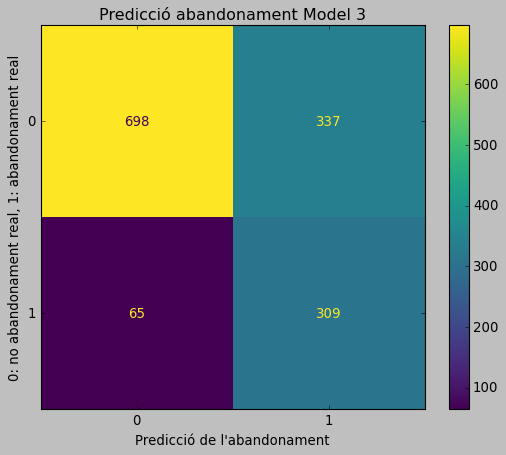

In [1050]:
model = tree.DecisionTreeClassifier(class_weight='balanced',max_features=20,max_depth=6,min_samples_split=202,random_state=5)
model.fit(X_train2, y_train)
    
   
y_pred2 = model.predict(X_test2)

exactitud = round(model.score(X_test2,y_test)*100,10)
f1=round(f1_score(y_test,y_pred2)*100,2)
print(f"->Exactitud: {exactitud}, f1: {f1}")
print(classification_report(y_test,y_pred2))
cm = confusion_matrix(y_test,y_pred2)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot()
plt.style.use('ggplot')
plt.xlabel("Predicció de l'abandonament")
plt.ylabel('0: no abandonament real, 1: abandonament real')
plt.title('Predicció abandonament Model 3')

Veiem que ara, contràriament amb el comportament de l'anterior model predictiu aquí la F1 ha baixat ligerament el que ens fa pensar que aquesta selecció no és de les millors. 

Per últim, farem una última selecció amb aquelles variables que tinguin un coeficient més gran de 0.5 (més ja no perquè ens quedaríem amb masses poques variables, i durant tot l'estudi hem vist que no només 3 variables afecten la taxa d'abandonament).

In [947]:
X_train3 = X_train.copy()
X_train3.drop('DeviceProtection',axis=1,inplace=True)
X_train3.drop('gender',axis=1,inplace=True)
X_train3.drop('Partner_Yes',axis=1,inplace=True)
X_train3.drop('PaymentMethod_Mailed check',axis=1,inplace=True)
X_train3.drop('SeniorCitizen',axis=1,inplace=True)
X_train3.drop('MultipleLines_No phone service',axis=1,inplace=True)
X_train3.drop('PaperlessBilling',axis=1,inplace=True)
X_train3.drop('OnlineBackup',axis=1,inplace=True)
X_train3.drop('PaymentMethod_Credit card (automatic)',axis=1,inplace=True)
X_train3.drop('Dependents',axis=1,inplace=True)
X_train3.drop('PhoneService',axis=1,inplace=True)
X_train3.drop('Partner_nan',axis=1,inplace=True)
X_train3.drop('StreamingTV',axis=1,inplace=True)
X_train3.drop('PaymentMethod_Electronic check',axis=1,inplace=True)
X_train3.drop('MultipleLines_Yes',axis=1,inplace=True)
X_train3.drop('StreamingMovies',axis=1,inplace=True)
X_train3.drop('TechSupport',axis=1,inplace=True)
X_train3.drop('OnlineSecurity',axis=1,inplace=True)

X_test3 = X_test.copy()
X_test3.drop('DeviceProtection',axis=1,inplace=True)
X_test3.drop('gender',axis=1,inplace=True)
X_test3.drop('Partner_Yes',axis=1,inplace=True)
X_test3.drop('PaymentMethod_Mailed check',axis=1,inplace=True)
X_test3.drop('SeniorCitizen',axis=1,inplace=True)
X_test3.drop('MultipleLines_No phone service',axis=1,inplace=True)
X_test3.drop('PaperlessBilling',axis=1,inplace=True)
X_test3.drop('OnlineBackup',axis=1,inplace=True)
X_test3.drop('PaymentMethod_Credit card (automatic)',axis=1,inplace=True)
X_test3.drop('Dependents',axis=1,inplace=True)
X_test3.drop('PhoneService',axis=1,inplace=True)
X_test3.drop('Partner_nan',axis=1,inplace=True)
X_test3.drop('StreamingTV',axis=1,inplace=True)
X_test3.drop('PaymentMethod_Electronic check',axis=1,inplace=True)
X_test3.drop('MultipleLines_Yes',axis=1,inplace=True)
X_test3.drop('StreamingMovies',axis=1,inplace=True)
X_test3.drop('TechSupport',axis=1,inplace=True)
X_test3.drop('OnlineSecurity',axis=1,inplace=True)

->Exactitud: 70.9723207949, f1: 59.94
              precision    recall  f1-score   support

           0       0.91      0.67      0.77      1035
           1       0.47      0.82      0.60       374

    accuracy                           0.71      1409
   macro avg       0.69      0.74      0.69      1409
weighted avg       0.79      0.71      0.73      1409



Text(0.5, 1.0, 'Predicció abandonament Model 4')

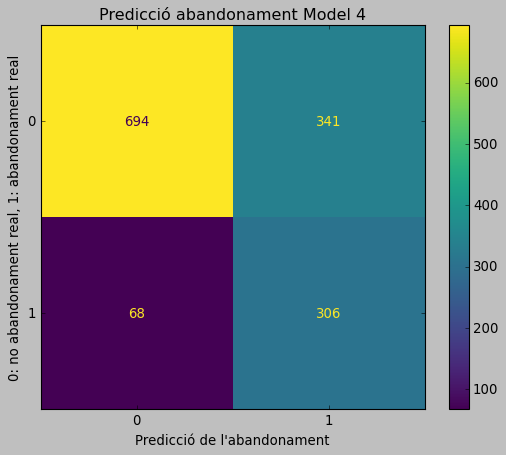

In [1060]:
model = tree.DecisionTreeClassifier(class_weight='balanced',max_features=20,max_depth=6,min_samples_split=202,random_state=5)
model.fit(X_train3, y_train)
    
   
y_pred3 = model.predict(X_test3)

exactitud = round(model.score(X_test3,y_test)*100,10)
f1=round(f1_score(y_test,y_pred3)*100,2)
print(f"->Exactitud: {exactitud}, f1: {f1}")
print(classification_report(y_test,y_pred3))
cm = confusion_matrix(y_test,y_pred3)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot()
plt.style.use('ggplot')
plt.xlabel("Predicció de l'abandonament")
plt.ylabel('0: no abandonament real, 1: abandonament real')
plt.title('Predicció abandonament Model 4')

Veiem que un altre cop la F1 descendeix, el que ens fa creure que en aquest cas ja hem arribat al model predictiu més bo i és el que està en segon lloc a aquest notebook (el de la primera selecció de variables).

En aquest punt i per finalitzar aquest notebook podem extreure una sèrie de conclusions sobre els models fets.

>Per començar, podem sentir-nos satisfets, ja que respecte a un primer model realitzat, aquell que tenia paràmetres predeterminats i on s'utilitzaven totes les variables, hem aconseguit una millora consistent en el seu rendiment. Més concretament hem passat d'un 50,6% de F1 (mitjana harmònica de la precisió i el recall, mètriques molt fiables en un model de classes desequilibrades com aquest) a un 63,4% que en aquest cas ho hem fet amb un segon model predictiu amb una sèrie de paràmetres i prescindint d'unes pques variables. 
Després també hem pogut observar que quant a seleccionar variables influents, en el model predictiu arbre de decisió funciona de la següent manera. Si prescindim de poques variables augmentem el seu rendiment, però ràpidament quan més augmentem el nombre de variables extretes disminuïm el mateix rendiment fins a arribar a ser pitjor que l'original. 